# Synthetic-100 regression: low rank-weight extension

This notebook extends the executed linear-kernel MiSTIC rank-weight sweep with
weights 0.00, 0.25, and 0.50. It uses the identical 20-member, ten-seed setup,
fixed training/blind split, forward-knee search, feature cap, parameter grid,
separate features/parameters, and final retuning.

The newly computed rows are saved separately and then merged with the previous
0.75–1.00 results for a complete comparison from 0 through 1.


In [1]:
import time
from pathlib import Path
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from scipy.stats import pearsonr
from sklearn.datasets import make_regression
from sklearn.feature_selection import RFE
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, KFold, ShuffleSplit, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR

repo_root = next(path for path in [Path.cwd(), *Path.cwd().parents]
                 if (path / "mistic" / "svmSet.py").exists())
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from mistic import combined_rank, cvSet, kernelWrapper, paramSet, score_svr, svmSet

sns.set_theme(style="whitegrid", context="notebook")
warnings.filterwarnings("ignore", category=FutureWarning)


Matplotlib is building the font cache; this may take a moment.


In [2]:
N_SAMPLES = 500
N_FEATURES = 100
N_INFORMATIVE = 10
N_REDUNDANT = 10
SIGNAL_FEATURES = set(range(N_INFORMATIVE + N_REDUNDANT))
DATA_SEED = 2026
BLIND_SET_SEED = 42
INNER_SEEDS = list(range(10))
MEMBER_COUNTS = [5, 10, 20]
TEST_SIZE = 0.25
INNER_VALIDATION_SIZE = 0.20
RANK_WEIGHT = 0.90
MAX_FEATURES = 20
ADDITION_FACTOR = 0.1
RFE_FEATURE_COUNT = 20
C_VALUES = [0.25, 1.0, 4.0]
GAMMA_VALUES = [2.0 ** exponent for exponent in (-9, -7, -5)]
EPSILON_VALUES = [0.05, 0.1, 0.2]

# Start with 10 informative plus 80 independent noise predictors. Insert 10
# noisy linear combinations of the informative block as redundant signal.
base_X, y_values, coefficients = make_regression(
    n_samples=N_SAMPLES, n_features=90, n_informative=N_INFORMATIVE,
    noise=20.0, shuffle=False, random_state=DATA_SEED, coef=True,
)
rng = np.random.default_rng(DATA_SEED)
mixing = rng.normal(size=(N_INFORMATIVE, N_REDUNDANT))
redundant = base_X[:, :N_INFORMATIVE] @ mixing
redundant += rng.normal(scale=0.10 * redundant.std(axis=0), size=redundant.shape)
X_values = np.column_stack([base_X[:, :N_INFORMATIVE], redundant, base_X[:, N_INFORMATIVE:]])
X = pd.DataFrame(X_values)
y = pd.Series(y_values, name="target")

X_train, X_blind, y_train_raw, y_blind_raw = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=BLIND_SET_SEED,
)
y_mean = y_train_raw.mean()
y_scale = y_train_raw.std(ddof=0)
y_train = (y_train_raw - y_mean) / y_scale
y_blind = (y_blind_raw - y_mean) / y_scale
print(f"Training rows: {len(X_train)}; fixed blind rows: {len(X_blind)}")
print(f"Training target mean={y_train.mean():.3g}, SD={y_train.std(ddof=0):.3g}")


Training rows: 375; fixed blind rows: 125
Training target mean=0, SD=1


In [3]:
def metric_row(y_true, predictions):
    r = pearsonr(y_true, predictions).statistic
    return {
        "r2": r2_score(y_true, predictions),
        "rmse": root_mean_squared_error(y_true, predictions),
        "mae": mean_absolute_error(y_true, predictions),
        "pearson_r2": r * r,
    }


def recovery(features):
    features = np.asarray(features, dtype=int)
    signal_count = len(set(features).intersection(SIGNAL_FEATURES))
    return signal_count / len(SIGNAL_FEATURES), signal_count / len(features)


def sklearn_grid(seed):
    return GridSearchCV(
        Pipeline([("scale", StandardScaler()), ("svr", SVR(kernel="rbf"))]),
        {"svr__C": C_VALUES, "svr__gamma": GAMMA_VALUES,
         "svr__epsilon": EPSILON_VALUES},
        scoring="r2", cv=KFold(n_splits=4, shuffle=True, random_state=seed),
        n_jobs=-1, refit=True,
    )


def fit_sklearn(features, seed):
    features = np.asarray(features, dtype=int)
    return sklearn_grid(seed).fit(X_train.iloc[:, features], y_train)


def fit_mistic(seed, num_models, rank_weight):
    scaler = StandardScaler().fit(X_train)
    X_scaled = scaler.transform(X_train)
    splits = cvSet(X_scaled, np.asarray(y_train), num_feature_medoids=20,
                   ensemble_validation_size=0.0)
    splitter = ShuffleSplit(n_splits=num_models,
                            test_size=INNER_VALIDATION_SIZE,
                            random_state=seed)
    generated = list(splitter.split(X_scaled, y_train))
    splits.train = [train for train, _ in generated]
    splits.test = [test for _, test in generated]
    splits.type = "regression_shuffle_split"
    ensemble = svmSet(
        SVR(kernel="precomputed"), splits,
        score_method=score_svr(weight=0.0).score,
        kernel=kernelWrapper(type="linear"),
        separate_feature_sets=True, separate_parameters=True,
    )
    grid = [
        paramSet(model={"C": c, "epsilon": epsilon}, kernel={})
        for c in C_VALUES for epsilon in EPSILON_VALUES
    ]
    ensemble.greedy_forward_selection(
        addition_factor=ADDITION_FACTOR, max_features=MAX_FEATURES,
        parameter_grid=grid,
        feature_ranker=combined_rank(weight=rank_weight).compute,
        set_for_rank="sample", tune_models_each_step=False,
        post_find_knee=True,
    )
    return scaler, ensemble, ensemble.find_knee(metric="score")


def ranked_unified_features(ensemble, limit):
    unified = set(np.asarray(ensemble.unified_features, dtype=int))
    ranked = np.asarray([f for f in ensemble.unified_sorted_features if f in unified], dtype=int)
    return ranked[:min(int(limit), len(ranked))]


def sklearn_row(method, features, seed, associated_members=0):
    features = np.asarray(features, dtype=int)
    model = fit_sklearn(features, seed)
    predictions = model.predict(X_blind.iloc[:, features])
    recall, precision = recovery(features)
    return {
        "seed": seed, "method": method, "num_models": 1,
        "associated_mistic_members": associated_members,
        "knee_feature_count": np.nan, "mean_member_features": np.nan,
        "num_unified_features": len(features),
        "top20_signal_recall": recall, "top20_signal_precision": precision,
        "member_disagreement": 0.0, "cv_best_score": model.best_score_,
        **metric_row(y_blind, predictions),
    }


## Run the low-weight extension

Only the three new weights are fitted. The previous results are loaded after
execution and merged without modification.


In [4]:
NEW_RANK_WEIGHTS = [0.00, 0.25, 0.50]
NUM_MODELS = 20
rows = []

for rank_weight in NEW_RANK_WEIGHTS:
    for seed in INNER_SEEDS:
        started = time.perf_counter()
        scaler, ensemble, knee_count = fit_mistic(seed, NUM_MODELS, rank_weight)
        X_blind_scaled = scaler.transform(X_blind)
        predictions = ensemble.predict(X_blind_scaled)
        top20 = ranked_unified_features(ensemble, 20)
        recall, precision = recovery(top20)
        selected_counts = np.asarray([len(f) for f in ensemble.features])
        member_predictions = np.column_stack([
            ensemble.predict(X_blind_scaled, model_index=i)
            for i in range(NUM_MODELS)
        ])
        residuals = np.asarray(y_blind)[:, None] - member_predictions
        residual_correlations = [
            abs(np.corrcoef(residuals[:, i], residuals[:, j])[0, 1])
            for i in range(NUM_MODELS) for j in range(i + 1, NUM_MODELS)
        ]
        rows.append({
            "seed": seed, "rank_weight": rank_weight,
            "method": f"Linear MiSTIC, weight={rank_weight:.2f}",
            "num_models": NUM_MODELS,
            "knee_feature_count": knee_count,
            "mean_member_features": selected_counts.mean(),
            "min_member_features": selected_counts.min(),
            "max_member_features": selected_counts.max(),
            "num_unified_features": len(ensemble.unified_features),
            "top20_signal_recall": recall,
            "top20_signal_precision": precision,
            "member_disagreement": 1 - np.mean(residual_correlations),
            "elapsed_seconds": time.perf_counter() - started,
            **metric_row(y_blind, predictions),
        })
        print(f"weight={rank_weight:.2f}, seed={seed}, knee={knee_count}, "
              f"elapsed={rows[-1]['elapsed_seconds']:.1f}s")

extension_results = pd.DataFrame(rows)
extension_path = repo_root / "validation/Synthetic100_regression_linear_rank_weight_low_extension_10seeds_results.csv"
extension_results.to_csv(extension_path, index=False)

previous = pd.read_csv(
    repo_root / "validation/Synthetic100_regression_linear_rank_weight_sweep_10seeds_results.csv"
)
results = pd.concat([extension_results, previous], ignore_index=True).sort_values(
    ["rank_weight", "seed"]
).reset_index(drop=True)
combined_path = repo_root / "validation/Synthetic100_regression_linear_rank_weight_full_sweep_10seeds_results.csv"
results.to_csv(combined_path, index=False)
results


Number of Features: 1, Score: 0.093


Number of Features: 10, Score: 0.198


Number of Features: 19, Score: 0.331


Number of Features: 20, Score: 0.373


Number of Features: 100, Score: 0.967


...

Number of Features: 19, Score: 0.919


Number of Features: 20, Score: 0.931


Number of Features: 100, Score: 0.967


weight=0.50, seed=9, knee=20, elapsed=25.7s


,seed,rank_weight,method,num_models,knee_feature_count,mean_member_features,min_member_features,max_member_features,num_unified_features,top20_signal_recall,top20_signal_precision,member_disagreement,elapsed_seconds,r2,rmse,mae,pearson_r2
0,0,0.0,"Linear MiSTIC, weight=0.00",20,20,20.0,20,20,100,0.25,0.250000,0.536740,23.375188,0.690060,0.477086,0.394929,0.786654
1,1,0.0,"Linear MiSTIC, weight=0.00",20,20,20.0,20,20,99,0.10,0.100000,0.461644,21.514269,0.617650,0.529893,0.433670,0.704439
2,2,0.0,"Linear MiSTIC, weight=0.00",20,20,20.0,20,20,99,0.30,0.300000,0.498990,30.633877,0.667762,0.493950,0.412990,0.731807
3,3,0.0,"Linear MiSTIC, weight=0.00",20,19,19.0,19,19,99,0.25,0.250000,0.477924,27.645811,0.661767,0.498386,0.413061,0.768978
4,4,0.0,"Linear MiSTIC, weight=0.00",20,19,19.0,19,19,96,0.15,0.150000,0.435029,30.775688,0.589387,0.549129,0.446550,0.688784
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85,5,1.0,"Linear MiSTIC, weight=1.00",20,10,10.0,10,10,17,0.65,0.764706,0.083035,21.093682,0.953263,0.185263,0.139927,0.953611
86,6,1.0,"Linear MiSTIC, weight=1.00",20,10,10.0,10,10,16,0.70,0.875000,0.099557,25.033498,0.948876,0.193762,0.147474,0.949299
87,7,1.0,"Linear MiSTIC, weight=1.00",20,10,10.0,10,10,17,0.65,0.764706,0.093834,26.140207,0.949727,0.192144,0.146103,0.950175
88,8,1.0,"Linear MiSTIC, weight=1.00",20,10,10.0,10,10,15,0.60,0.800000,0.064222,25.364137,0.944654,0.201604,0.153436,0.945197


In [5]:
metrics = ["r2", "rmse", "mae", "pearson_r2", "knee_feature_count",
           "mean_member_features", "num_unified_features", "top20_signal_recall",
           "top20_signal_precision", "member_disagreement", "elapsed_seconds"]
summary = results.groupby("rank_weight")[metrics].agg(["mean", "std"])
summary.round(4)


r2            rmse             mae         pearson_r2  \
               mean     std    mean     std    mean     std       mean   
rank_weight                                                              
0.00         0.6218  0.0663  0.5250  0.0475  0.4328  0.0377     0.7061   
0.25         0.8945  0.0372  0.2745  0.0484  0.2270  0.0401     0.9208   
0.50         0.9597  0.0054  0.1717  0.0115  0.1376  0.0090     0.9611   
0.75         0.9716  0.0012  0.1445  0.0030  0.1127  0.0018     0.9717   
0.80         0.9681  0.0097  0.1517  0.0213  0.1191  0.0181     0.9684   
0.85         0.9514  0.0036  0.1889  0.0068  0.1479  0.0063     0.9515   
0.90         0.9523  0.0027  0.1872  0.0054  0.1444  0.0051     0.9525   
0.95         0.9496  0.0051  0.1922  0.0098  0.1461  0.0080     0.9500   
1.00         0.9471  0.0032  0.1970  0.0061  0.1494  0.0051     0.9476   

                    knee_feature_count          ... num_unified_features  \
                std               mean     std  ...                 mean   
rank_weight                                     ...                        
0.00         0.0693               19.7  0.4830  ...                 98.4   
0.25         0.0259               20.0  0.0000  ...                 94.6   
0.50         0.0046               20.0  0.0000  ...                 88.0   
0.75         0.0012               19.0  0.0000  ...                 69.5   
0.80         0.0095               17.2  3.7947  ...                 56.6   
0.85         0.0036               10.0  0.0000  ...                 24.4   
0.90         0.0027               10.0  0.0000  ...                 21.0   
0.95         0.0050               10.0  0.0000  ...                 17.8   
1.00         0.0032               10.0  0.0000  ...                 16.3   

                     top20_signal_recall         top20_signal_precision  \
                 std                mean     std                   mean   
rank_weight                                                               
0.00          1.1738               0.230  0.0919                 0.2300   
0.25          1.4298               0.655  0.0926                 0.6550   
0.50          2.0000               0.750  0.0667                 0.7500   
0.75          2.4152               0.840  0.0394                 0.8400   
0.80         16.4330               0.845  0.0599                 0.8450   
0.85          2.5473               0.765  0.0242                 0.7650   
0.90          1.7638               0.740  0.0211                 0.7524   
0.95          1.6865               0.690  0.0394                 0.7839   
1.00          0.6749               0.650  0.0236                 0.7984   

                    member_disagreement         elapsed_seconds          
                std                mean     std            mean     std  
rank_weight                                                              
0.00         0.0919              0.4616  0.0588         26.7205  3.6218  
0.25         0.0926              0.6508  0.0264         26.0726  3.5860  
0.50         0.0667              0.5296  0.0498         27.2381  4.4447  
0.75         0.0394              0.2532  0.0311         26.1303  3.5606  
0.80         0.0599              0.2373  0.1313         25.5132  2.8731  
0.85         0.0242              0.3830  0.0586         23.4359  2.8133  
0.90         0.0295              0.2614  0.0447         22.5101  2.8892  
0.95         0.0691              0.1205  0.0483         23.3072  3.5897  
1.00         0.0353              0.0874  0.0134         24.3905  2.1775  

[9 rows x 22 columns]

In [6]:
best_weight = results.groupby("rank_weight")["r2"].mean().idxmax()
baseline = results.query("rank_weight == @best_weight").set_index("seed")
paired_rows = []
for weight in sorted(results["rank_weight"].unique()):
    if np.isclose(weight, best_weight):
        continue
    candidate = results.query("rank_weight == @weight").set_index("seed")
    for metric in ["r2", "rmse", "mae", "pearson_r2"]:
        best_advantage = baseline[metric] - candidate[metric]
        if metric in ["rmse", "mae"]:
            best_advantage = -best_advantage
        paired_rows.append({
            "comparison": f"best weight {best_weight:.2f} minus {weight:.2f}",
            "metric": metric, "mean_best_advantage": best_advantage.mean(),
            "std_difference": best_advantage.std(ddof=1),
            "best_wins": int((best_advantage > 0).sum()),
            "ties": int((best_advantage == 0).sum()),
            "best_losses": int((best_advantage < 0).sum()),
        })
paired = pd.DataFrame(paired_rows)
print(f"Best mean blind R² weight: {best_weight:.2f}")
paired.round(4)


Best mean blind R² weight: 0.75


,comparison,metric,mean_best_advantage,std_difference,best_wins,ties,best_losses
0,best weight 0.75 minus 0.00,r2,0.3497,0.0662,10,0,0
1,best weight 0.75 minus 0.00,rmse,0.3806,0.0472,10,0,0
2,best weight 0.75 minus 0.00,mae,0.3202,0.0370,10,0,0
3,best weight 0.75 minus 0.00,pearson_r2,0.2656,0.0691,10,0,0
4,best weight 0.75 minus 0.25,r2,0.0771,0.0365,10,0,0
5,best weight 0.75 minus 0.25,rmse,0.1300,0.0466,10,0,0
6,best weight 0.75 minus 0.25,mae,0.1143,0.0390,10,0,0
7,best weight 0.75 minus 0.25,pearson_r2,0.0508,0.0253,10,0,0
8,best weight 0.75 minus 0.50,r2,0.0119,0.0047,10,0,0
9,best weight 0.75 minus 0.50,rmse,0.0272,0.0098,10,0,0


/var/folders/q_/4g9fzlq94y3d38pwjs5rt9f40000gn/T/ipykernel_80175/49756026.py:26: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(data=comparison, y="method", x="r2", order=order,


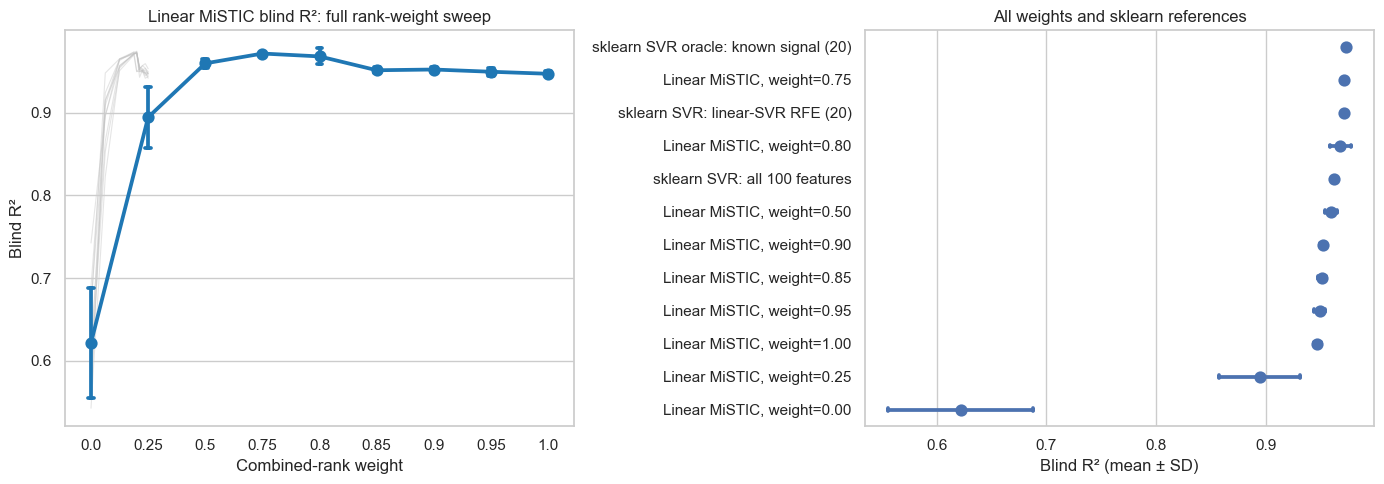

In [7]:
reference_results = pd.read_csv(
    repo_root / "validation/Synthetic100_regression_linear_member_count_10seeds_results.csv"
)
reference_names = [
    "sklearn SVR oracle: known signal (20)",
    "sklearn SVR: linear-SVR RFE (20)",
    "sklearn SVR: all 100 features",
]
references = reference_results[reference_results["method"].isin(reference_names)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.pointplot(data=results, x="rank_weight", y="r2", errorbar="sd",
              capsize=0.10, color="tab:blue", ax=axes[0])
for _, seed_data in results.groupby("seed"):
    axes[0].plot(seed_data["rank_weight"], seed_data["r2"],
                 color="0.75", alpha=0.4, linewidth=0.8, zorder=0)
axes[0].set_title("Linear MiSTIC blind R²: full rank-weight sweep")
axes[0].set_xlabel("Combined-rank weight")
axes[0].set_ylabel("Blind R²")

comparison = pd.concat([
    results[["seed", "method", "r2"]],
    references[["seed", "method", "r2"]],
], ignore_index=True)
order = comparison.groupby("method")["r2"].mean().sort_values(ascending=False).index
sns.pointplot(data=comparison, y="method", x="r2", order=order,
              errorbar="sd", join=False, capsize=0.08, ax=axes[1])
axes[1].set_title("All weights and sklearn references")
axes[1].set_xlabel("Blind R² (mean ± SD)")
axes[1].set_ylabel("")
plt.tight_layout()
plot_path = repo_root / "validation/Synthetic100_regression_linear_rank_weight_full_sweep_10seeds.png"
fig.savefig(plot_path, dpi=160, bbox_inches="tight")
plt.show()


## Interpretation notes

Blind performance is retrospective and must not be used as an operational
weight-selection criterion. All seeds share the same blind observations and
measure sensitivity to inner model construction rather than independent-test
uncertainty.
